# Exploratory Data Analysis (EDA)

This notebook explores trends in mutual fund performance, assets under management (AUM), SIP inflows, category inflows, and investor growth between 2022 and 2025. The objective is to identify industry trends and generate actionable insights for investors and fund houses.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



## Key Findings

The visualizations below highlight the major patterns observed in the dataset, including AUM growth, SIP participation trends, category-wise inflows, and industry folio expansion.

In [6]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

In [7]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [8]:
fund_master.shape

(40, 15)

In [9]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [2]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

In [4]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [12]:
nav.shape

(46000, 3)

In [13]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [14]:
nav.isnull().sum()

amfi_code    0
date         0
nav          0
dtype: int64

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

In [17]:
nav["amfi_code"].nunique()

40

In [16]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [18]:
nav["amfi_code"].unique()

array([119551, 119552, 119598, 119599, 119120, 100016, 125497, 100033,
       125498, 100025, 120503, 120504, 120505, 120506, 120507, 118632,
       118633, 118634, 118635, 118636, 120841, 120842, 120843, 120844,
       119092, 119093, 119094, 119095, 101206, 101207, 101208, 102885,
       102886, 102887, 148567, 148568, 148569, 149322, 149323, 149324])

In [19]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

In [20]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [21]:
aum.shape

(90, 5)

In [22]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

In [23]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [24]:
sip.shape

(48, 6)

In [25]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

In [26]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [27]:
category.shape

(144, 3)

In [28]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

In [29]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [30]:
folio.shape

(21, 6)

In [31]:
investor = pd.read_csv("../data/raw/08_investor_transactions.csv")

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [33]:
investor.shape
holdings.shape

(322, 8)

In [35]:
nav["date"] = pd.to_datetime(nav["date"])

In [34]:
investor.shape

(32778, 13)

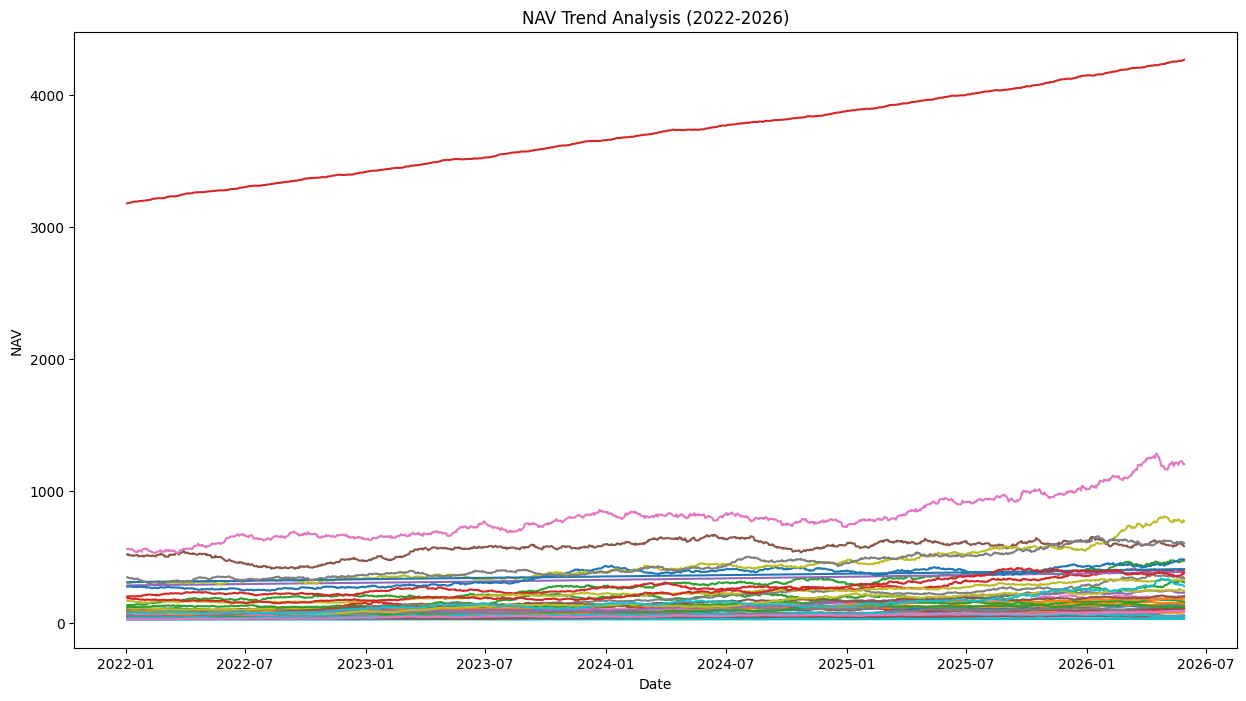

In [36]:
plt.figure(figsize=(15,8))

for code in nav["amfi_code"].unique():
    temp = nav[nav["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"])

plt.title("NAV Trend Analysis (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.show()

In [3]:
plt.figure(figsize=(15,8))

for code in nav["amfi_code"].unique():
    temp = nav[nav["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"])

plt.title("NAV Trend Analysis (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.show()

NameError: name 'nav' is not defined

<Figure size 1500x800 with 0 Axes>

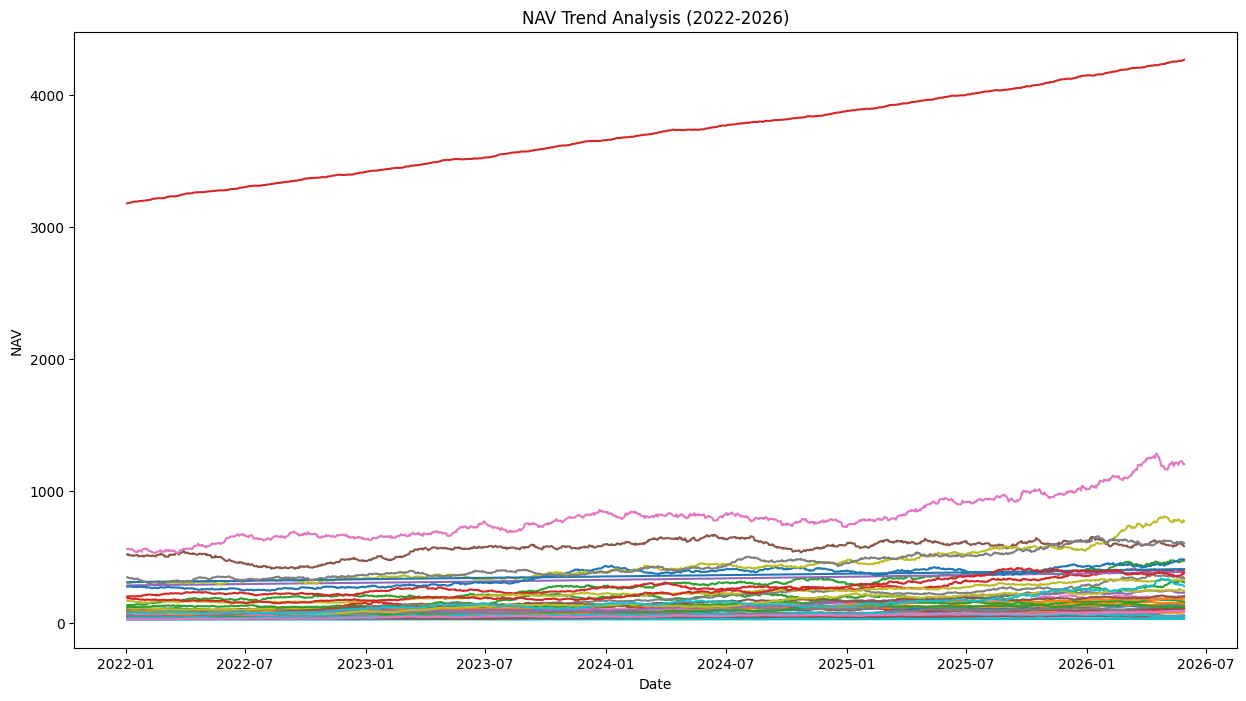

In [5]:
plt.figure(figsize=(15,8))

for code in nav["amfi_code"].unique():
    temp = nav[nav["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"])

plt.title("NAV Trend Analysis (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.show()

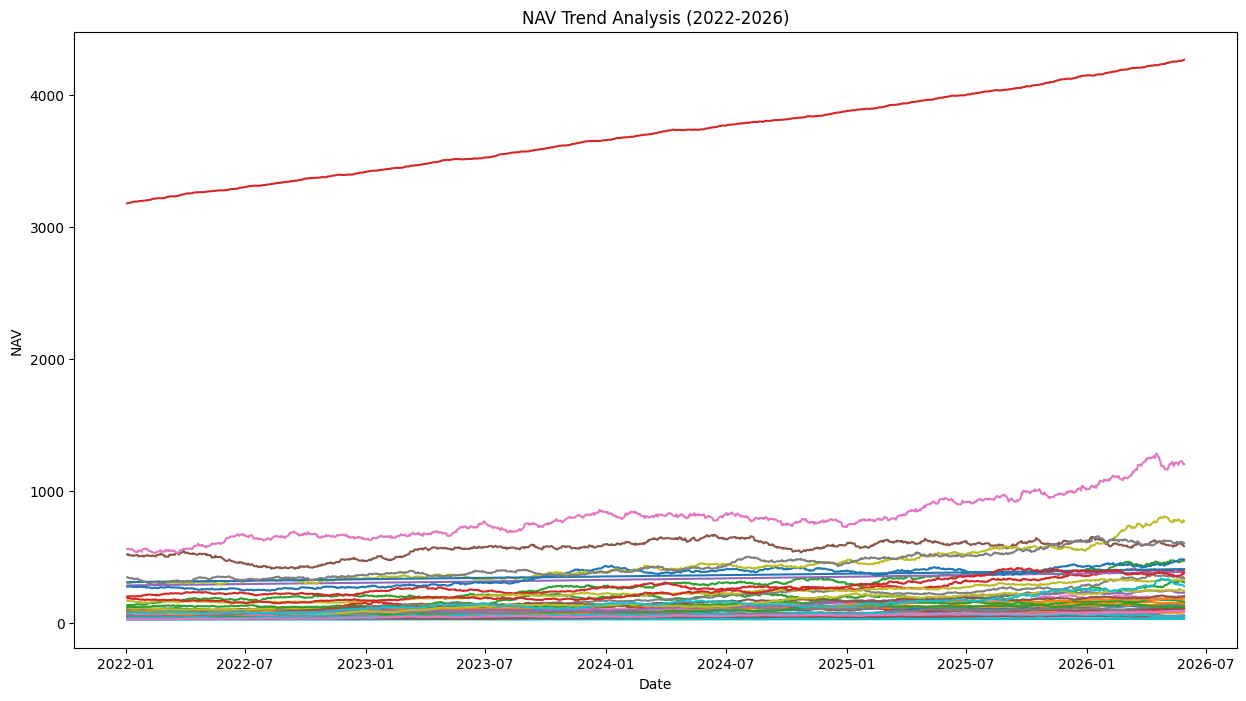

In [6]:
plt.figure(figsize=(15,8))

for code in nav["amfi_code"].unique():
    temp = nav[nav["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"])

plt.title("NAV Trend Analysis (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.savefig("../charts/nav_trend_analysis.png")

plt.show()

In [7]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

In [8]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


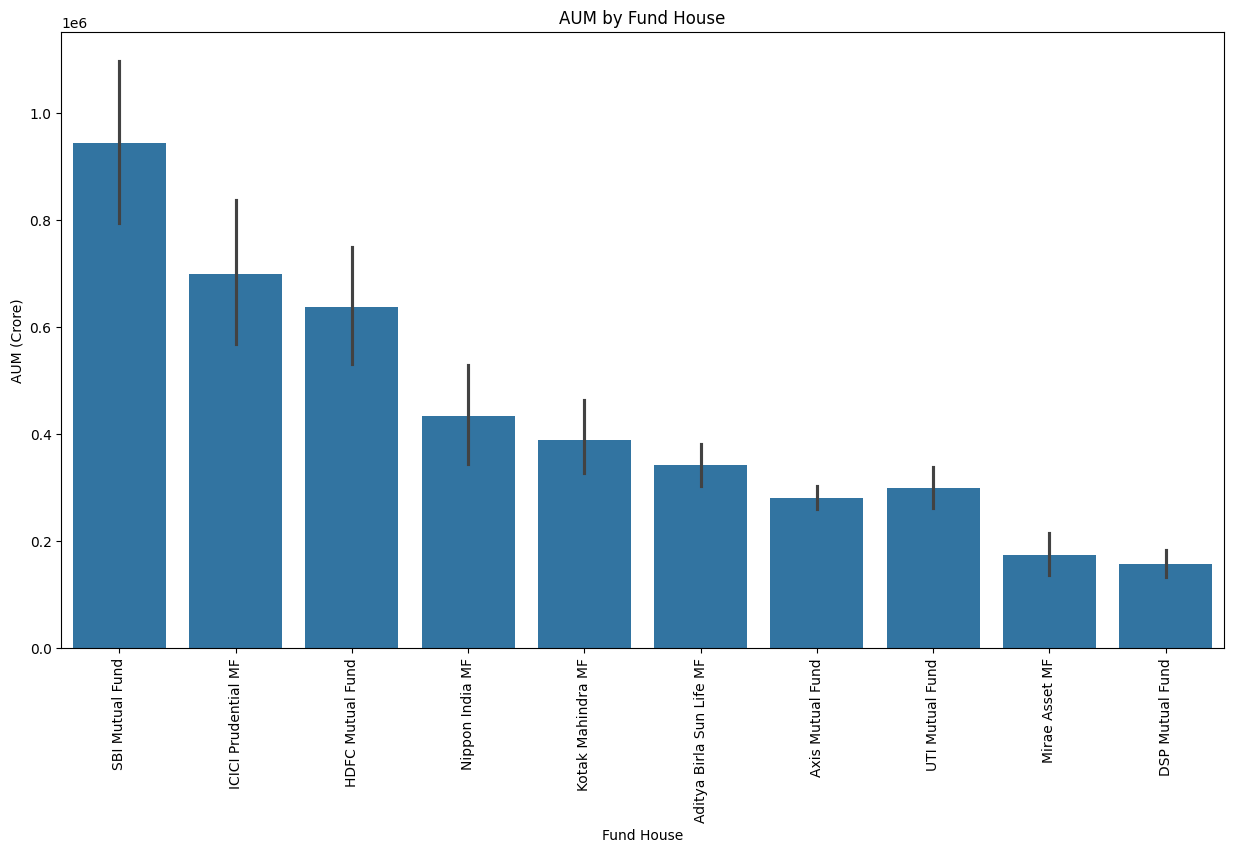

In [9]:
import seaborn as sns

plt.figure(figsize=(15,8))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_crore"
)

plt.xticks(rotation=90)
plt.title("AUM by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore)")

plt.show()

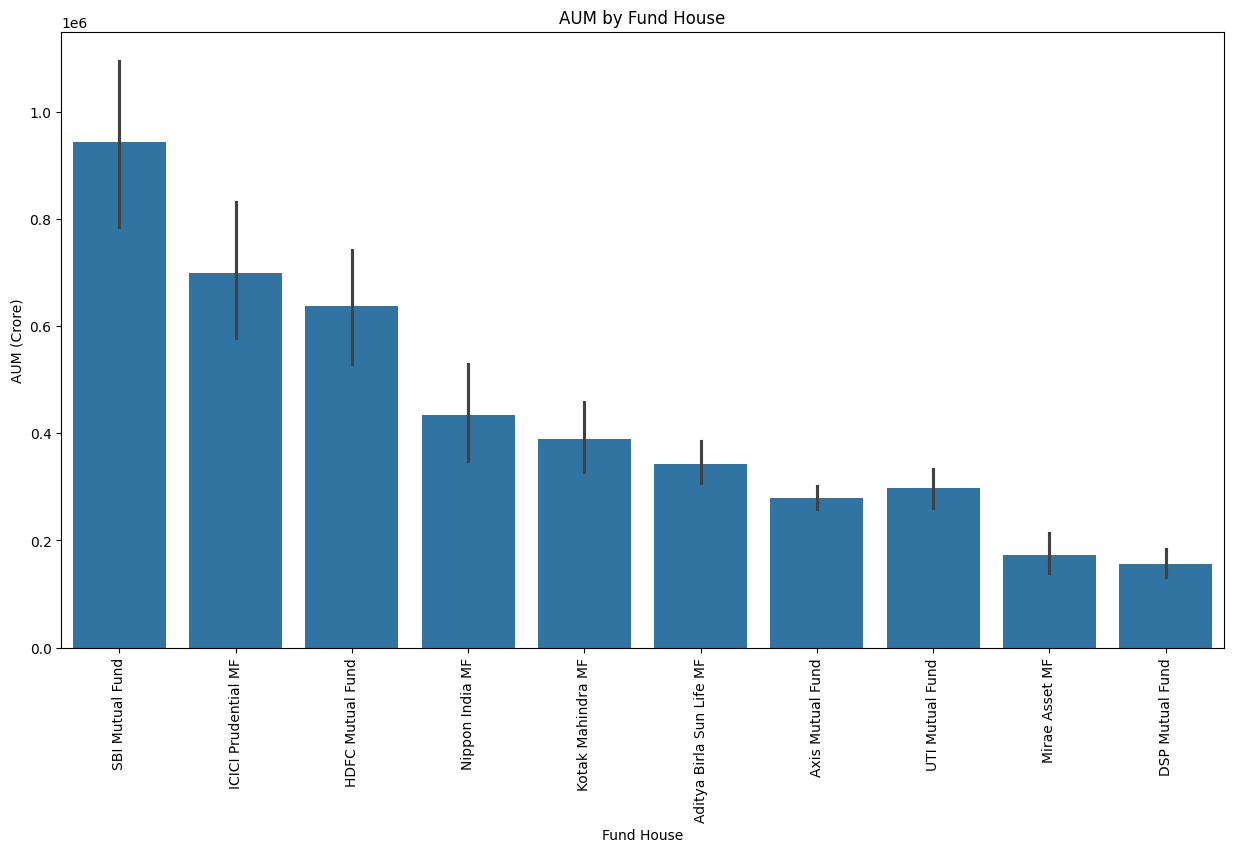

In [10]:
plt.figure(figsize=(15,8))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_crore"
)

plt.xticks(rotation=90)
plt.title("AUM by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore)")

plt.savefig("../charts/aum_by_fund_house.png")

plt.show()

In [11]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

In [12]:
sip["month"] = pd.to_datetime(sip["month"])

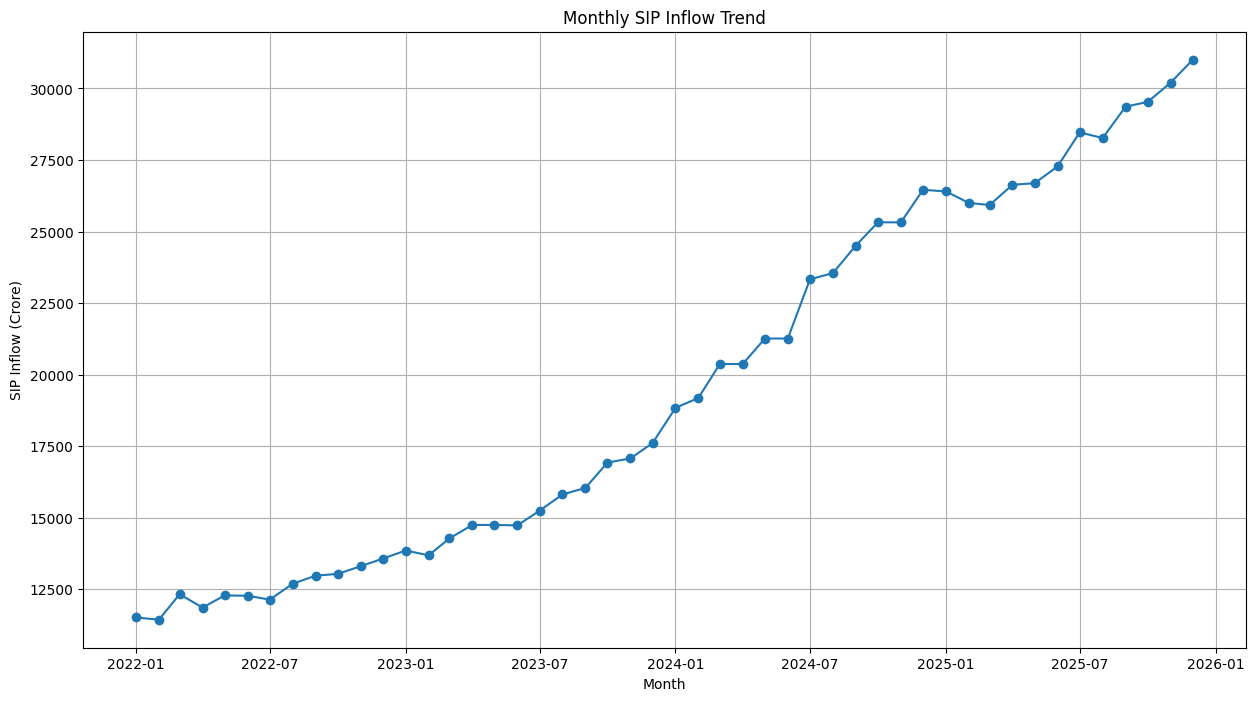

In [13]:
plt.figure(figsize=(15,8))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

plt.show()

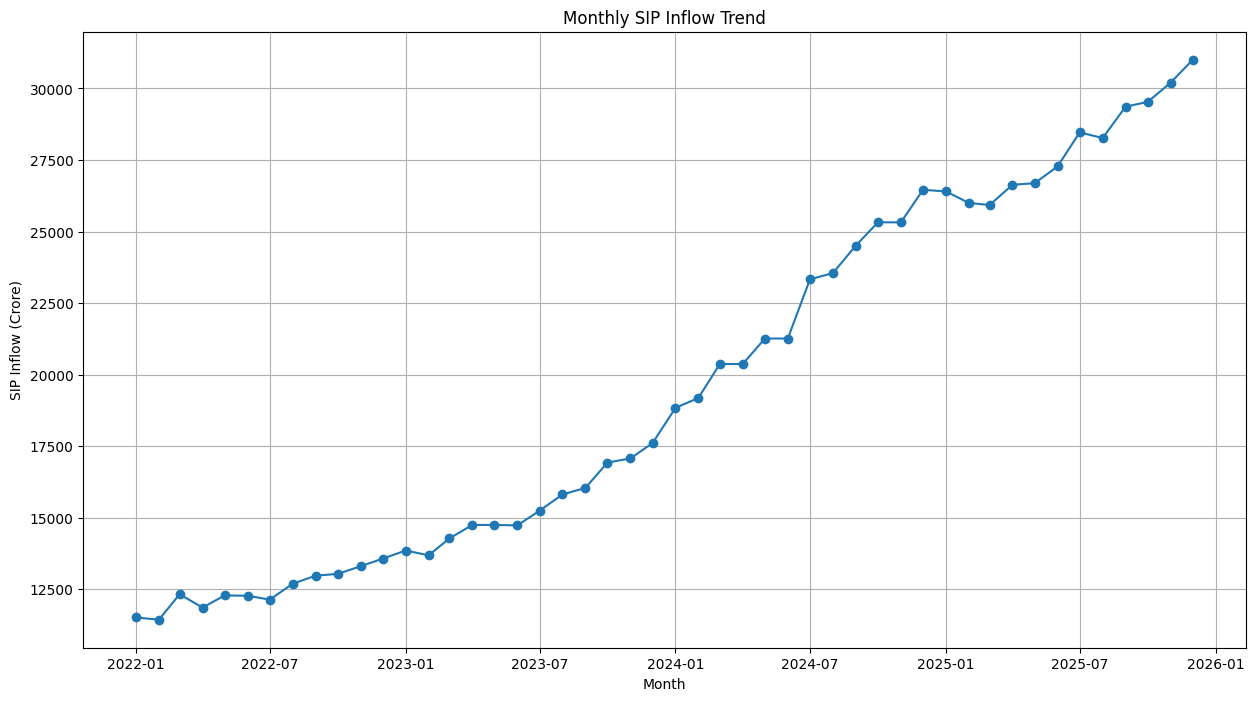

In [14]:
plt.figure(figsize=(15,8))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

plt.savefig("../charts/sip_inflow_trend.png")

plt.show()

In [15]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

In [16]:
category["month"] = pd.to_datetime(category["month"])

In [17]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


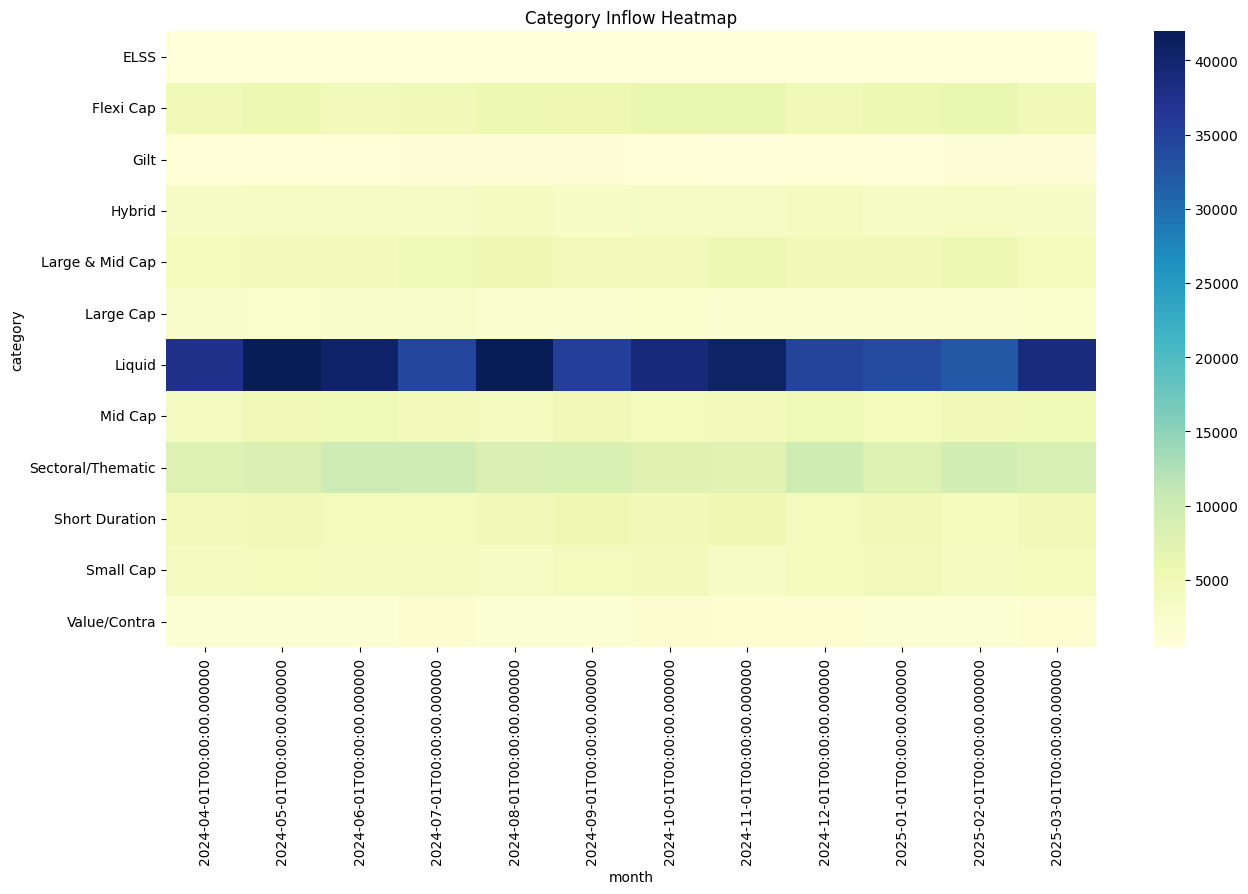

In [18]:
plt.figure(figsize=(15,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.show()

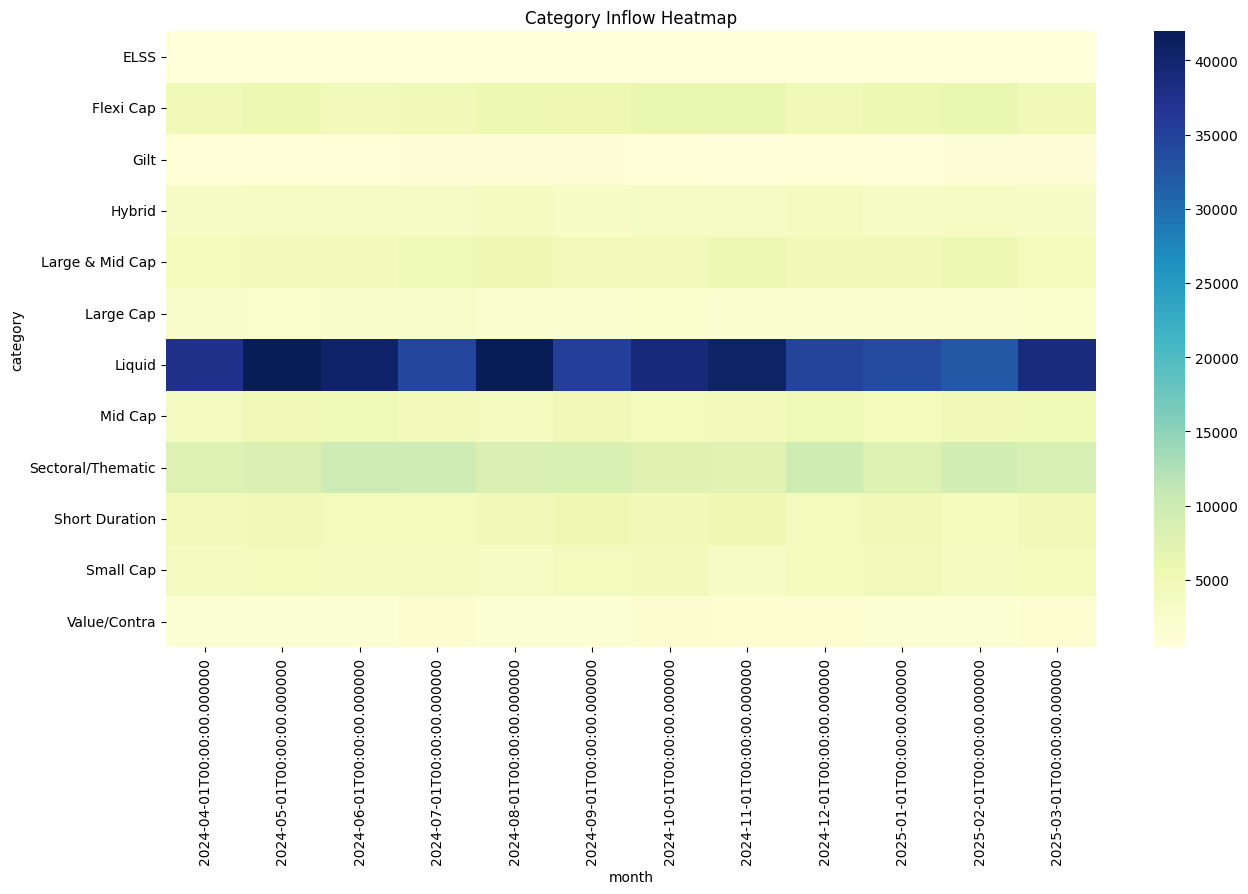

In [19]:
plt.figure(figsize=(15,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.savefig("../charts/category_inflow_heatmap.png")

plt.show()

In [ ]:
plt.figure(figsize=(15,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.savefig("../charts/category_inflow_heatmap.png")

plt.show()

In [20]:
investor = pd.read_csv("../data/raw/08_investor_transactions.csv")

In [21]:
investor.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

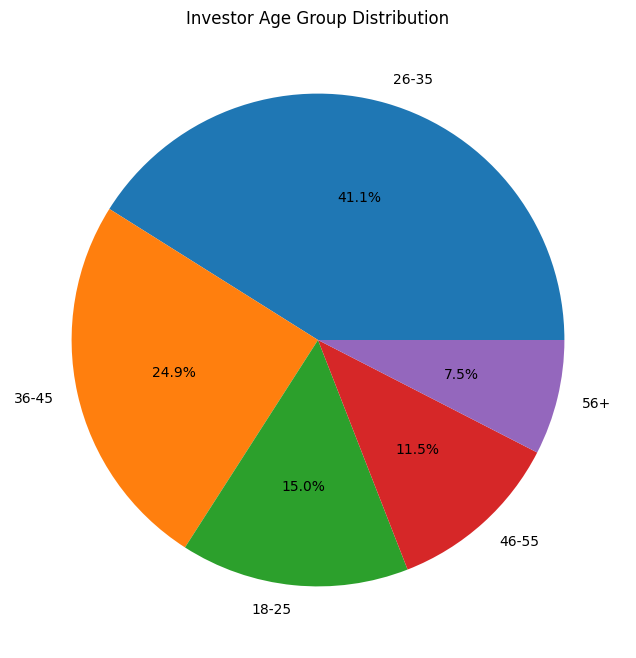

In [22]:
plt.figure(figsize=(8,8))

investor["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")

plt.show()

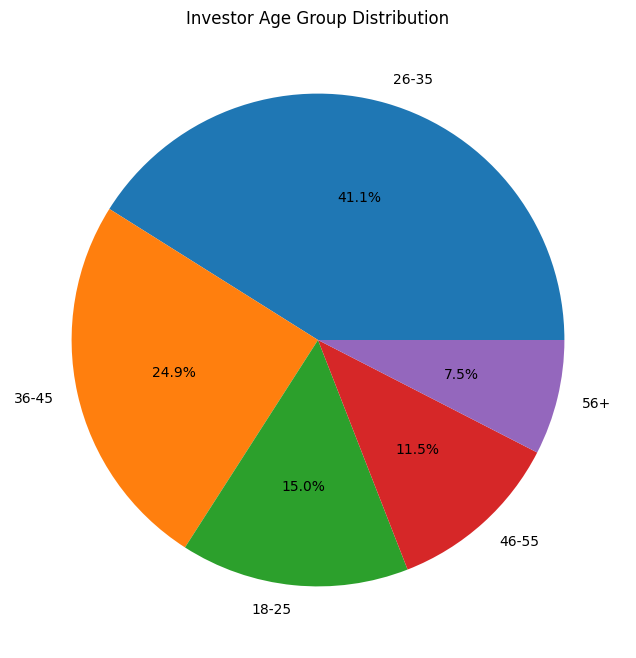

In [23]:
plt.figure(figsize=(8,8))

investor["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")

plt.savefig("../charts/age_group_distribution.png")

plt.show()

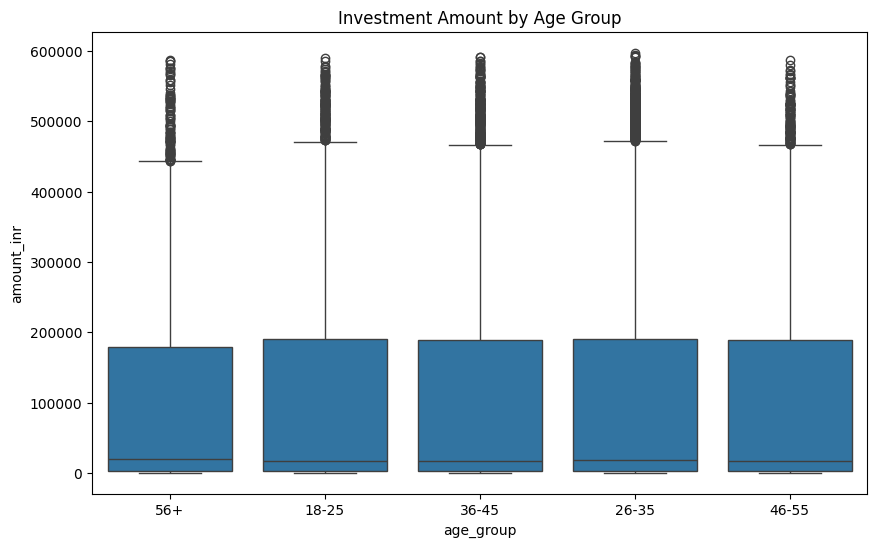

In [24]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.show()

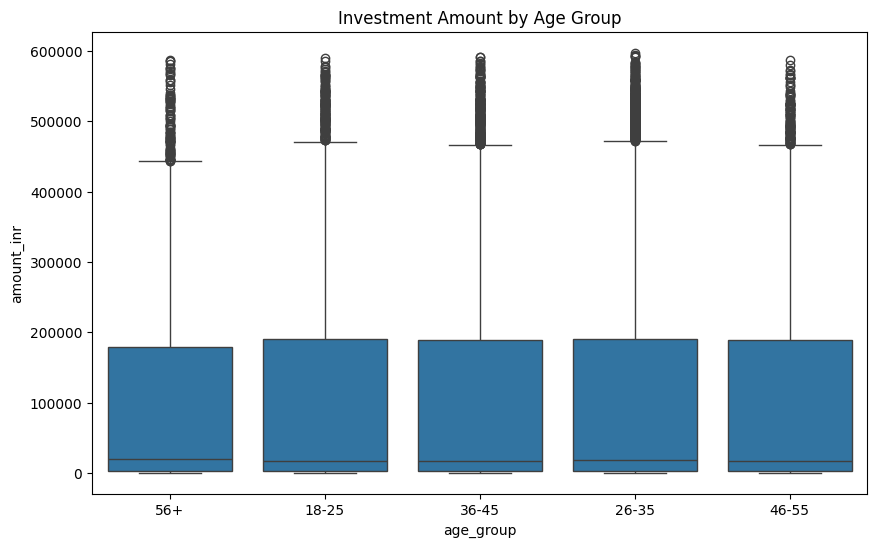

In [25]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.savefig("../charts/investment_by_age_group.png")

plt.show()

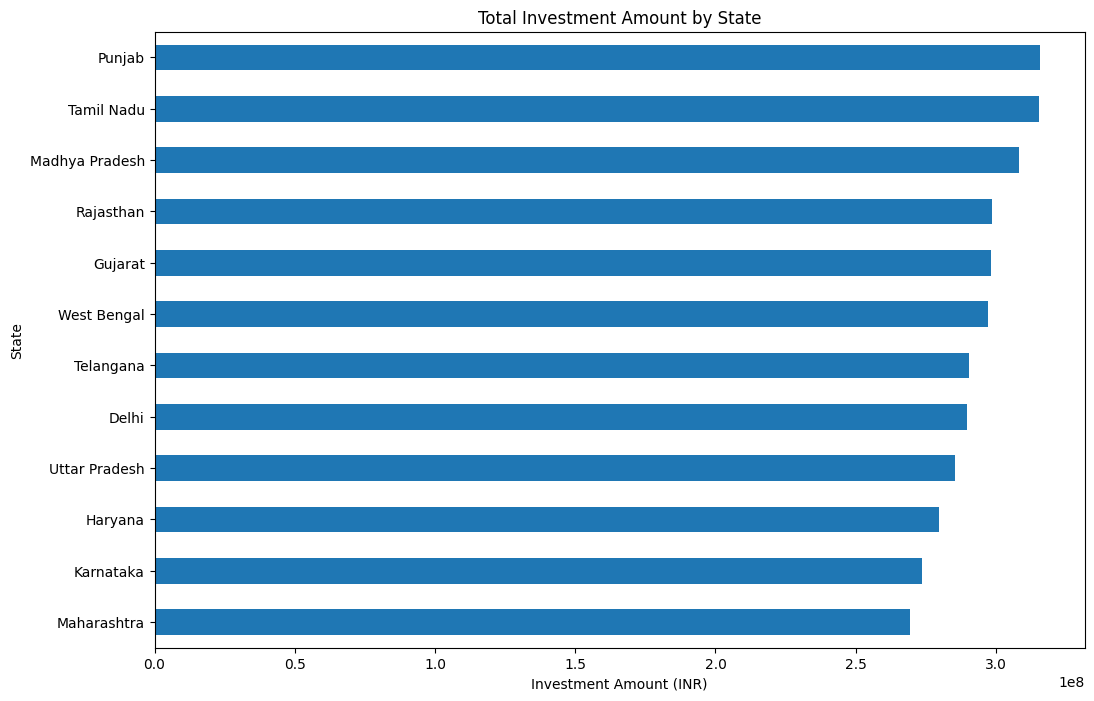

In [26]:
state_data = investor.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(12,8))

state_data.plot(kind="barh")

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (INR)")
plt.ylabel("State")

plt.show()

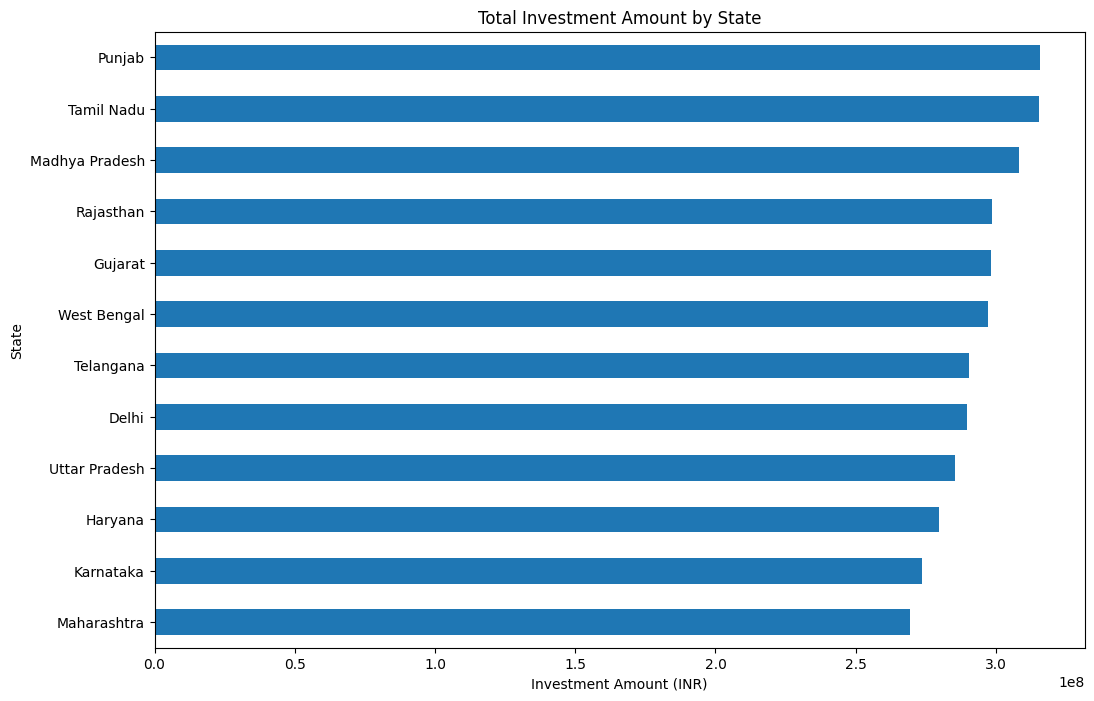

In [27]:
state_data = investor.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(12,8))

state_data.plot(kind="barh")

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (INR)")
plt.ylabel("State")

plt.savefig("../charts/investment_by_state.png")

plt.show()

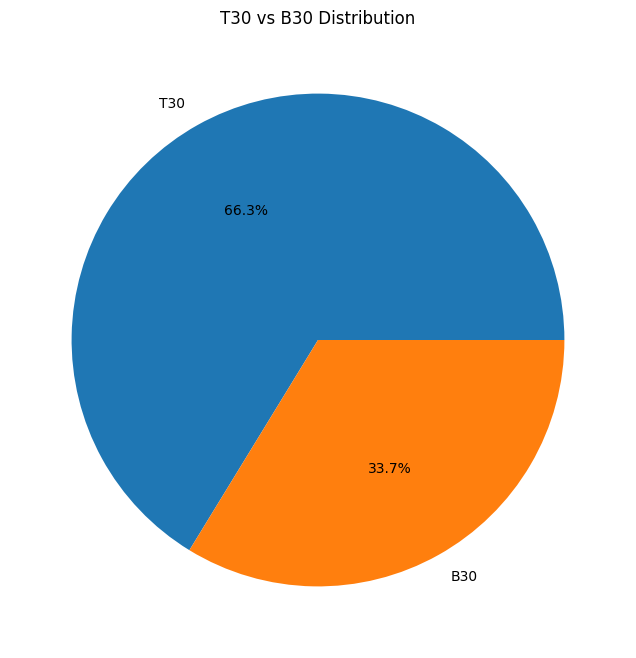

In [28]:
plt.figure(figsize=(8,8))

investor["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")
plt.ylabel("")

plt.show()

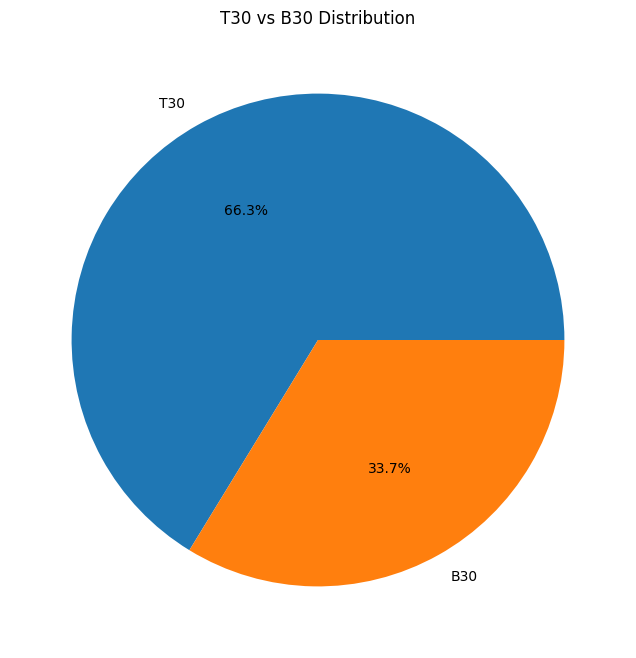

In [29]:
plt.figure(figsize=(8,8))

investor["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")
plt.ylabel("")

plt.savefig("../charts/t30_b30_distribution.png")

plt.show()

In [30]:
folio["month"] = pd.to_datetime(folio["month"])

NameError: name 'folio' is not defined

In [31]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

In [32]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [33]:
folio["month"] = pd.to_datetime(folio["month"])

In [34]:
folio["month"] = pd.to_datetime(folio["month"])

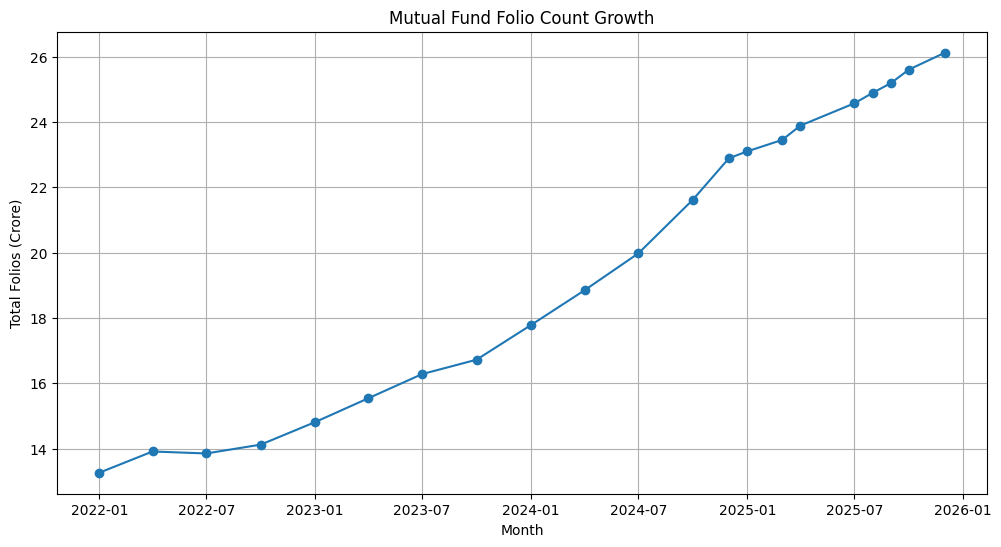

In [35]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Mutual Fund Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.show()

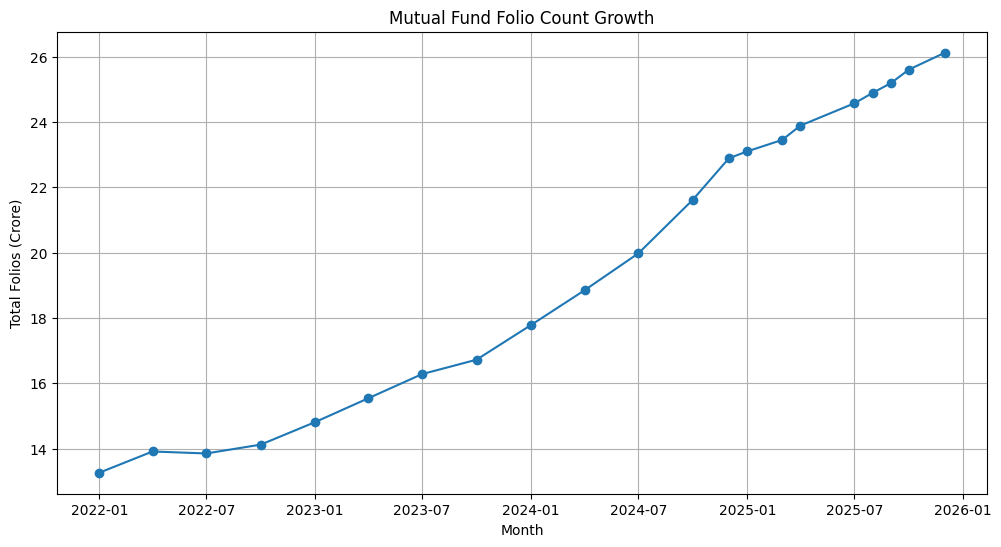

In [36]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Mutual Fund Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.savefig("../charts/folio_count_growth.png")

plt.show()

In [37]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [38]:
corr_df = nav.pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

In [39]:
corr = corr_df.corr()

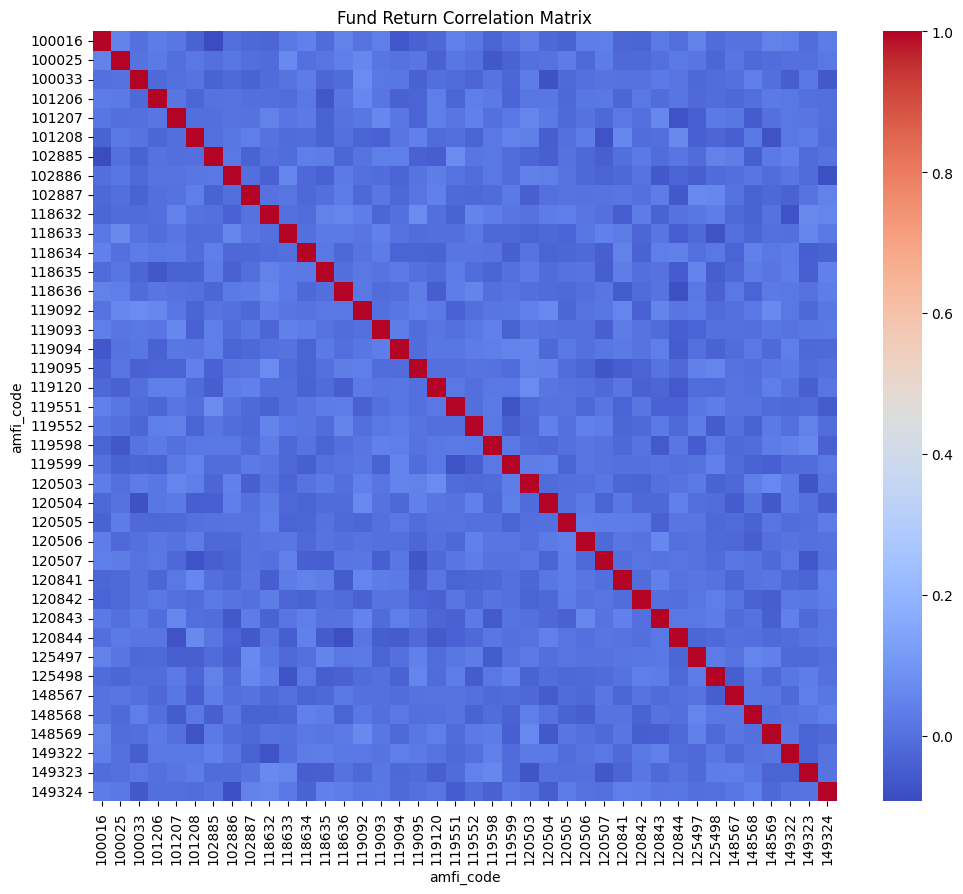

In [40]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Fund Return Correlation Matrix")

plt.show()

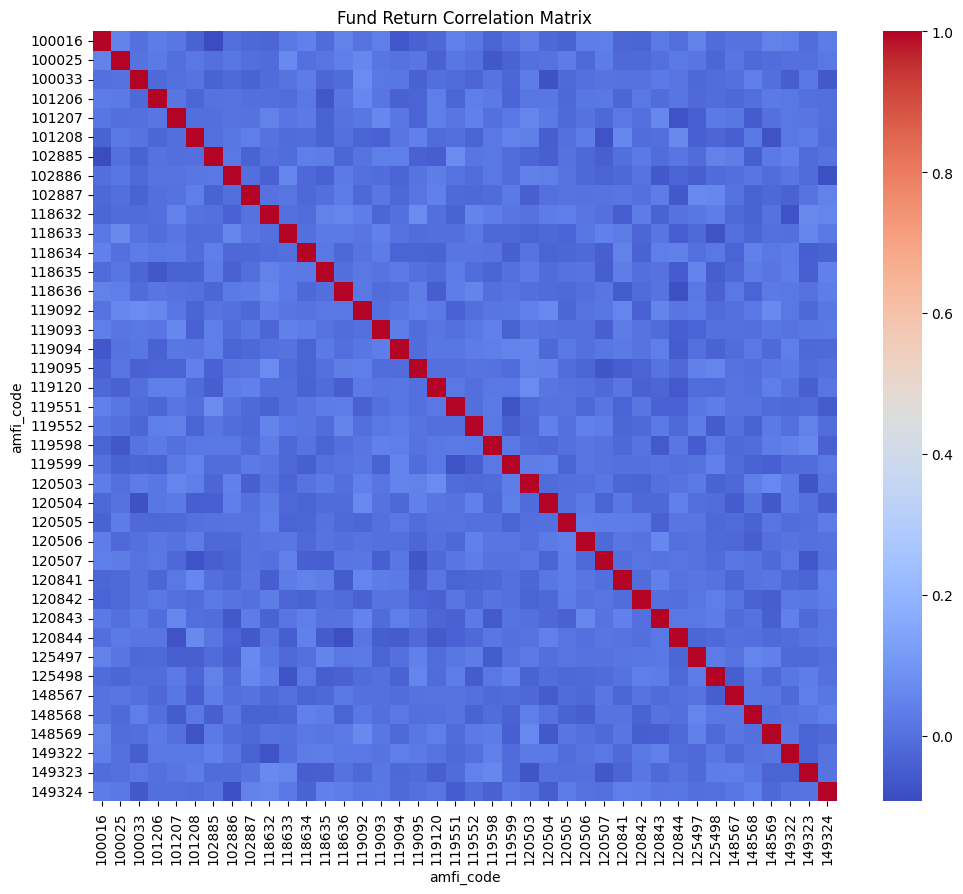

In [41]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Fund Return Correlation Matrix")

plt.savefig("../charts/correlation_matrix.png")

plt.show()

In [42]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [43]:
sector = holdings.groupby(
    "sector"
)["weight_pct"].sum()

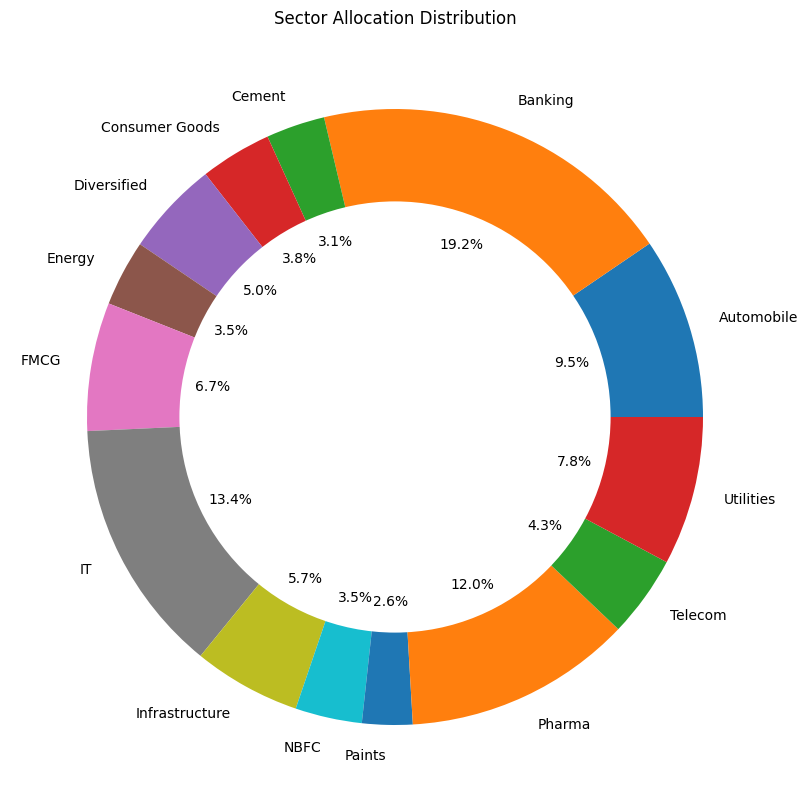

In [44]:
plt.figure(figsize=(10,10))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Distribution")

plt.show()

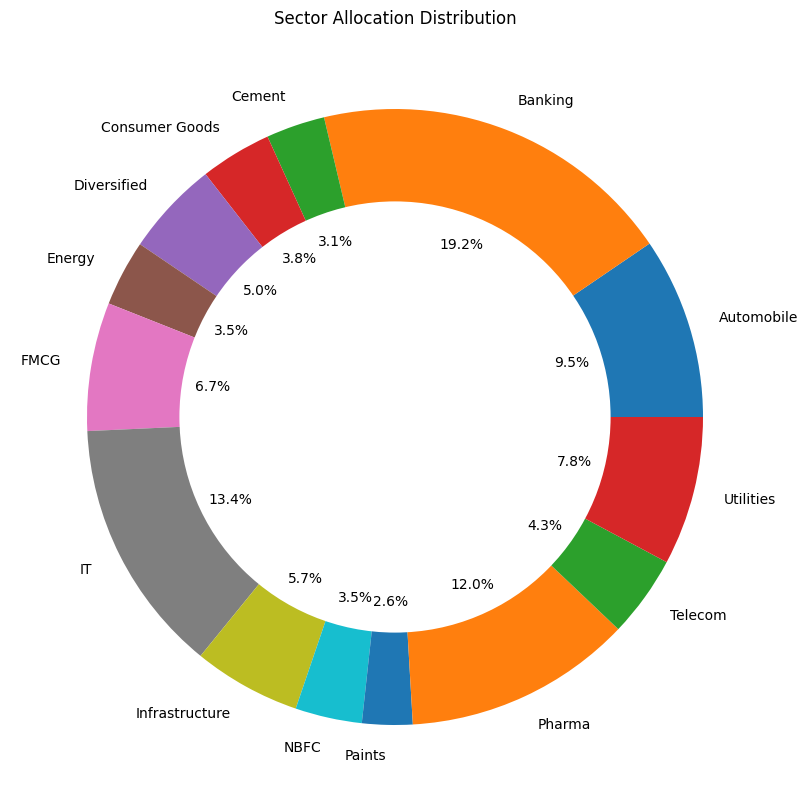

In [45]:
plt.figure(figsize=(10,10))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Distribution")

plt.savefig("../charts/sector_allocation_distribution.png")

plt.show()

# Key EDA Findings

1. NAV values of mutual fund schemes generally showed an upward trend from 2022 to 2026.

2. SBI Mutual Fund maintained the highest AUM among the selected fund houses.

3. SIP inflows showed consistent growth across the observed period.

4. December 2025 recorded one of the highest SIP inflow values.

5. Certain mutual fund categories attracted significantly higher net inflows compared to others.

6. The majority of investors belonged to the 26–35 and 36–45 age groups.

7. Investment patterns varied across states, with a few states contributing the largest transaction volumes.

8. T30 cities contributed a major share of mutual fund investments compared to B30 cities.

9. Mutual fund returns exhibited positive correlations across most schemes.

10. Portfolio holdings were concentrated in a few dominant sectors, indicating sector-wise allocation preferences.